In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Menampilkan grafik langsung di dalam notebook
%matplotlib inline

In [9]:
# Tentukan path relatif dari folder notebooks ke folder data
data_dir = '../data/raw/'
frames_dir = os.path.join(data_dir, 'frames')
gt_path = os.path.join(data_dir, 'mall_gt.mat')

# Memuat file MATLAB yang berisi anotasi
print("Memuat anotasi ground truth...")
gt_data = loadmat(gt_path)

# Mengambil data frame dari struktur array MATLAB
# Struktur mall_gt: frame[0] berisi list data per frame
frames_annotation = gt_data['frame'][0]
total_frames = len(frames_annotation)

print(f"Berhasil! Total frame yang memiliki anotasi: {total_frames} frame")

Memuat anotasi ground truth...
Berhasil! Total frame yang memiliki anotasi: 2000 frame


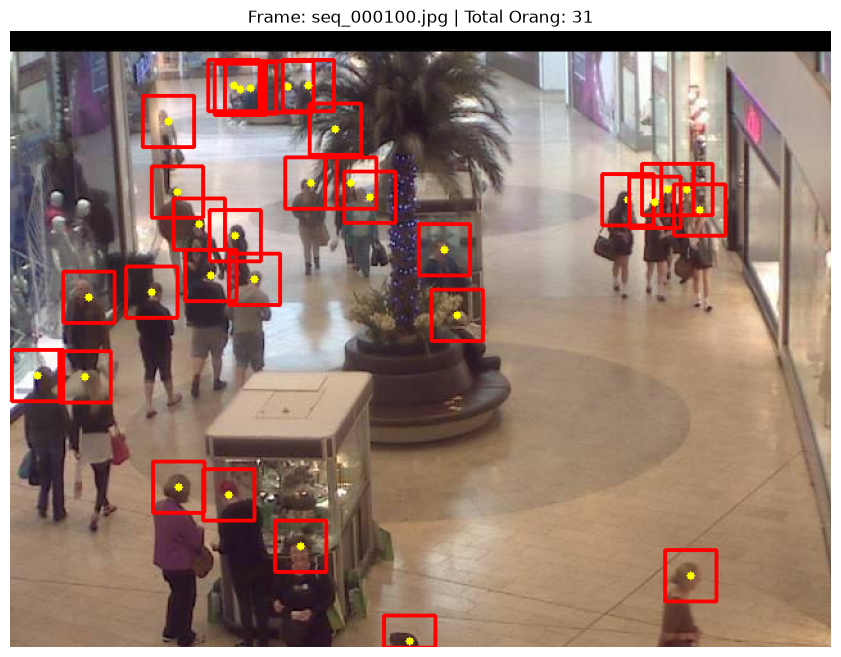

In [10]:
def visualize_bbox(frame_idx, box_size=50):
    """
    Menampilkan gambar dengan bounding box hasil konversi dari titik kepala.
    frame_idx: Urutan frame (dimulai dari 1)
    box_size: Ukuran sisi kotak dalam piksel
    """
    # Nama file gambar Mall Dataset menggunakan format seq_000001.jpg
    img_name = f"seq_{frame_idx:06d}.jpg" 
    img_path = os.path.join(frames_dir, img_name)
    
    # Membaca gambar menggunakan OpenCV
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Gambar {img_name} tidak ditemukan di {img_path}")
        return
        
    # OpenCV menggunakan format BGR, kita ubah ke RGB untuk Matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Mengambil koordinat (x, y) untuk frame tersebut
    # Index Python dimulai dari 0, jadi frame_idx dikurangi 1
    points = frames_annotation[frame_idx - 1][0][0][0] 
    
    # Menggambar bounding box untuk setiap titik koordinat
    for pt in points:
        x, y = int(pt[0]), int(pt[1])
        
        # Menghitung batas kotak (kiri, atas, kanan, bawah)
        x_min = max(0, x - box_size // 2)
        y_min = max(0, y - box_size // 2)
        x_max = min(img.shape[1], x + box_size // 2)
        y_max = min(img.shape[0], y + box_size // 2)
        
        # Gambar kotak warna merah
        cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
        # Gambar titik tengah warna kuning sebagai referensi asli
        cv2.circle(img, (x, y), 3, (255, 255, 0), -1)
        
    # Menampilkan hasil gambar
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title(f"Frame: {img_name} | Total Orang: {len(points)}")
    plt.axis('off')
    plt.show()

# Mari kita uji coba visualisasi pada frame ke-100
visualize_bbox(100, box_size=40)

In [11]:
import shutil

# 1. Menyiapkan folder tujuan (Processed Data)
processed_dir = '../data/processed/'
images_dir = os.path.join(processed_dir, 'images')
labels_dir = os.path.join(processed_dir, 'labels')

os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

# Parameter ukuran kotak (sesuaikan dengan hasil visualisasi sebelumnya)
box_size = 40 

print("Mulai mengekspor dataset ke format YOLO...")

# 2. Melakukan looping ke seluruh frame
for frame_idx in range(1, total_frames + 1):
    img_name = f"seq_{frame_idx:06d}.jpg"
    img_path = os.path.join(frames_dir, img_name)
    
    # Ambil resolusi gambar
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_height, img_width = img.shape[:2]
    
    # Salin gambar ke folder processed
    dest_img_path = os.path.join(images_dir, img_name)
    shutil.copy(img_path, dest_img_path)
    
    # 3. Membuat file .txt untuk label YOLO
    txt_name = f"seq_{frame_idx:06d}.txt"
    txt_path = os.path.join(labels_dir, txt_name)
    
    points = frames_annotation[frame_idx - 1][0][0][0]
    
    with open(txt_path, 'w') as f:
        for pt in points:
            x, y = pt[0], pt[1]
            
            # Normalisasi koordinat untuk YOLO (skala 0.0 - 1.0)
            x_center = x / img_width
            y_center = y / img_height
            width = box_size / img_width
            height = box_size / img_height
            
            # Memastikan nilai tidak melebihi batas 1.0 atau kurang dari 0.0
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            
            # Class ID selalu 0 karena kita hanya mendeteksi 1 kelas yaitu "Person"
            class_id = 0
            
            # Tulis ke file
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

print("Selesai! Gambar dan label YOLO berhasil disimpan di folder data/processed/")

Mulai mengekspor dataset ke format YOLO...
Selesai! Gambar dan label YOLO berhasil disimpan di folder data/processed/


In [12]:
import os
import shutil

processed_dir = '../data/processed/'
images_dir = os.path.join(processed_dir, 'images')
labels_dir = os.path.join(processed_dir, 'labels')

# Membuat sub-folder train dan val
for split in ['train', 'val']:
    os.makedirs(os.path.join(images_dir, split), exist_ok=True)
    os.makedirs(os.path.join(labels_dir, split), exist_ok=True)

# Mengambil semua gambar yang ada di data/processed/images
all_images = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
total_images = len(all_images)

# Membagi: 80% Train (1600 gambar), 20% Val (400 gambar)
train_split = int(total_images * 0.8)

print(f"Membagi {total_images} dataset: {train_split} untuk training, {total_images - train_split} untuk validasi...")

for i, img_name in enumerate(all_images):
    txt_name = img_name.replace('.jpg', '.txt')
    
    # Tentukan folder tujuan (train atau val)
    split_folder = 'train' if i < train_split else 'val'
    
    # Pindahkan gambar dan label ke sub-folder masing-masing
    shutil.move(os.path.join(images_dir, img_name), os.path.join(images_dir, split_folder, img_name))
    
    label_path = os.path.join(labels_dir, txt_name)
    if os.path.exists(label_path):
        shutil.move(label_path, os.path.join(labels_dir, split_folder, txt_name))

print("Selesai membagi data!")

# Membuat file dataset.yaml yang diwajibkan oleh YOLO
yaml_path = os.path.join(processed_dir, 'dataset.yaml')

# YOLOv8 membutuhkan absolute path agar tidak error saat training
abs_path = os.path.abspath(processed_dir).replace('\\', '/')

yaml_content = f"""
path: {abs_path}
train: images/train
val: images/val

names:
  0: person
"""

with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())
    
print(f"File dataset.yaml berhasil dibuat di: {yaml_path}")

Membagi 2000 dataset: 1600 untuk training, 400 untuk validasi...


Selesai membagi data!
File dataset.yaml berhasil dibuat di: ../data/processed/dataset.yaml
